# Home Credit Default Risk Predictor
## Baseline Model Performance Comparison

## 1. Imports & Configuration

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier

from sklearn.metrics import (
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    classification_report,
    confusion_matrix,
    RocCurveDisplay
)

# --- Fixed Random Seed ---
RANDOM_STATE = 42
TEST_SIZE = 0.2

## 2. Load Feature-Engineered Data

In [2]:
train = pd.read_csv('train_fe.csv')

print(f'Dataset shape : {train.shape}')
print(f'Target distribution :')
print(train['TARGET'].value_counts())
print(f'\nDefault rate   : {train["TARGET"].mean():.4f} ({train["TARGET"].mean()*100:.2f}%)')

Dataset shape : (307511, 66)
Target distribution :
TARGET
0    282686
1     24825
Name: count, dtype: int64

Default rate   : 0.0807 (8.07%)


## 3. Prepare Features & Target

In [3]:
# Separate features and target
X = train.drop(columns=['SK_ID_CURR', 'TARGET'])
y = train['TARGET']

print(f'Features shape : {X.shape}')
print(f'Target shape   : {y.shape}')
print(f'\nFeature columns ({X.shape[1]}):')
for i, col in enumerate(X.columns, 1):
    print(f'  {i:>2}. {col}')

Features shape : (307511, 64)
Target shape   : (307511,)

Feature columns (64):
   1. NAME_CONTRACT_TYPE
   2. CODE_GENDER
   3. FLAG_OWN_CAR
   4. FLAG_OWN_REALTY
   5. CNT_CHILDREN
   6. AMT_INCOME_TOTAL
   7. AMT_CREDIT
   8. AMT_ANNUITY
   9. AMT_GOODS_PRICE
  10. NAME_EDUCATION_TYPE
  11. EXT_SOURCE_1
  12. EXT_SOURCE_2
  13. EXT_SOURCE_3
  14. ORGANIZATION_TYPE
  15. AGE
  16. YEARS_EMPLOYED
  17. NAME_TYPE_SUITE_Family
  18. NAME_TYPE_SUITE_Group of people
  19. NAME_TYPE_SUITE_Other_A
  20. NAME_TYPE_SUITE_Other_B
  21. NAME_TYPE_SUITE_Spouse, partner
  22. NAME_TYPE_SUITE_Unaccompanied
  23. NAME_INCOME_TYPE_Commercial associate
  24. NAME_INCOME_TYPE_Maternity leave
  25. NAME_INCOME_TYPE_Pensioner
  26. NAME_INCOME_TYPE_State servant
  27. NAME_INCOME_TYPE_Student
  28. NAME_INCOME_TYPE_Unemployed
  29. NAME_INCOME_TYPE_Working
  30. NAME_FAMILY_STATUS_Married
  31. NAME_FAMILY_STATUS_Separated
  32. NAME_FAMILY_STATUS_Single / not married
  33. NAME_FAMILY_STATUS_Unknown
  

## 4. Train-Validation Split

In [4]:
X_train, X_val, y_train, y_val = train_test_split(
    X, y, test_size=TEST_SIZE, random_state=RANDOM_STATE, stratify=y
)

print(f'Training set   : {X_train.shape[0]:,} samples')
print(f'Validation set : {X_val.shape[0]:,} samples')
print(f'\nTraining default rate   : {y_train.mean():.4f}')
print(f'Validation default rate : {y_val.mean():.4f}')

Training set   : 246,008 samples
Validation set : 61,503 samples

Training default rate   : 0.0807
Validation default rate : 0.0807


## 5. Feature Scaling

In [5]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled = scaler.transform(X_val)

print(f'Scaling complete.')
print(f'  Train - mean: {X_train_scaled.mean():.6f}, std: {X_train_scaled.std():.6f}')
print(f'  Val   - mean: {X_val_scaled.mean():.6f}, std: {X_val_scaled.std():.6f}')

Scaling complete.
  Train - mean: 0.000000, std: 1.000000
  Val   - mean: 0.000172, std: 1.008941


## 6. Evaluation Helper

In [6]:
def evaluate_model(model, X_val, y_val, model_name):
    """
    Evaluate a trained classifier and return a dict of metrics.
    
    Parameters
    ----------
    model : fitted sklearn/xgboost classifier
    X_val : validation features
    y_val : validation labels
    model_name : str - display name for the model
    
    Returns
    -------
    dict with keys: Precision, Recall, F1, ROC-AUC
    """
    y_pred = model.predict(X_val)
    y_prob = model.predict_proba(X_val)[:, 1]
    
    precision = precision_score(y_val, y_pred)
    recall = recall_score(y_val, y_pred)
    f1 = f1_score(y_val, y_pred)
    roc_auc = roc_auc_score(y_val, y_prob)
    
    print(f'=== {model_name} ===')
    print(f'  Precision : {precision:.4f}')
    print(f'  Recall    : {recall:.4f}')
    print(f'  F1-Score  : {f1:.4f}')
    print(f'  ROC-AUC   : {roc_auc:.4f}')
    print()
    print(classification_report(y_val, y_pred, target_names=['No Default', 'Default']))
    print()
    
    return {
        'Model': model_name,
        'Precision': round(precision, 4),
        'Recall': round(recall, 4),
        'F1-Score': round(f1, 4),
        'ROC-AUC': round(roc_auc, 4)
    }

results = []

## 7. Model 1 — Logistic Regression

In [7]:
%%time

lr_model = LogisticRegression(
    random_state=RANDOM_STATE,
    max_iter=500,
    class_weight='balanced'
)
lr_model.fit(X_train_scaled, y_train)

lr_results = evaluate_model(lr_model, X_val_scaled, y_val, 'Logistic Regression')
results.append(lr_results)

=== Logistic Regression ===
  Precision : 0.1605
  Recall    : 0.6733
  F1-Score  : 0.2592
  ROC-AUC   : 0.7437

              precision    recall  f1-score   support

  No Default       0.96      0.69      0.80     56538
     Default       0.16      0.67      0.26      4965

    accuracy                           0.69     61503
   macro avg       0.56      0.68      0.53     61503
weighted avg       0.90      0.69      0.76     61503


CPU times: total: 3.83 s
Wall time: 2.52 s


## 8. Model 2 — Random Forest

In [8]:
%%time

rf_model = RandomForestClassifier(
    n_estimators=100,
    random_state=RANDOM_STATE,
    class_weight='balanced',
    n_jobs=-1
)
rf_model.fit(X_train_scaled, y_train)

rf_results = evaluate_model(rf_model, X_val_scaled, y_val, 'Random Forest')
results.append(rf_results)

=== Random Forest ===
  Precision : 0.5769
  Recall    : 0.0060
  F1-Score  : 0.0120
  ROC-AUC   : 0.7312

              precision    recall  f1-score   support

  No Default       0.92      1.00      0.96     56538
     Default       0.58      0.01      0.01      4965

    accuracy                           0.92     61503
   macro avg       0.75      0.50      0.48     61503
weighted avg       0.89      0.92      0.88     61503


CPU times: total: 3min 9s
Wall time: 58.3 s


## 9. Model 3 — XGBoost

In [9]:
%%time

# Calculate scale_pos_weight for imbalanced data
neg_count = (y_train == 0).sum()
pos_count = (y_train == 1).sum()
scale_ratio = neg_count / pos_count

xgb_model = XGBClassifier(
    n_estimators=100,
    random_state=RANDOM_STATE,
    scale_pos_weight=scale_ratio,
    eval_metric='logloss',
    use_label_encoder=False,
    n_jobs=-1
)
xgb_model.fit(X_train_scaled, y_train)

xgb_results = evaluate_model(xgb_model, X_val_scaled, y_val, 'XGBoost')
results.append(xgb_results)

=== XGBoost ===
  Precision : 0.1760
  Recall    : 0.6429
  F1-Score  : 0.2764
  ROC-AUC   : 0.7559

              precision    recall  f1-score   support

  No Default       0.96      0.74      0.83     56538
     Default       0.18      0.64      0.28      4965

    accuracy                           0.73     61503
   macro avg       0.57      0.69      0.55     61503
weighted avg       0.90      0.73      0.79     61503


CPU times: total: 11 s
Wall time: 4.73 s


## 10. Baseline Model Comparison

In [11]:
comparison_df = pd.DataFrame(results)
comparison_df = comparison_df.set_index('Model')

print('=' * 60)
print('  BASELINE MODEL COMPARISON — Home Credit Default Risk')
print('=' * 60)
print()

comparison_df

  BASELINE MODEL COMPARISON — Home Credit Default Risk



,Precision,Recall,F1-Score,ROC-AUC
Model,,,,
Logistic Regression,0.1605,0.6733,0.2592,0.7437
Random Forest,0.5769,0.0060,0.0120,0.7312
XGBoost,0.1760,0.6429,0.2764,0.7559


In [12]:
# Highlight the best model for each metric
print('Best Model per Metric:')
print('-' * 50)
for metric in ['Precision', 'Recall', 'F1-Score', 'ROC-AUC']:
    best_model = comparison_df[metric].idxmax()
    best_value = comparison_df[metric].max()
    print(f'  {metric:<12} : {best_model} ({best_value:.4f})')

Best Model per Metric:
--------------------------------------------------
  Precision    : Random Forest (0.5769)
  Recall       : Logistic Regression (0.6733)
  F1-Score     : XGBoost (0.2764)
  ROC-AUC      : XGBoost (0.7559)


## 11. Visual Comparison

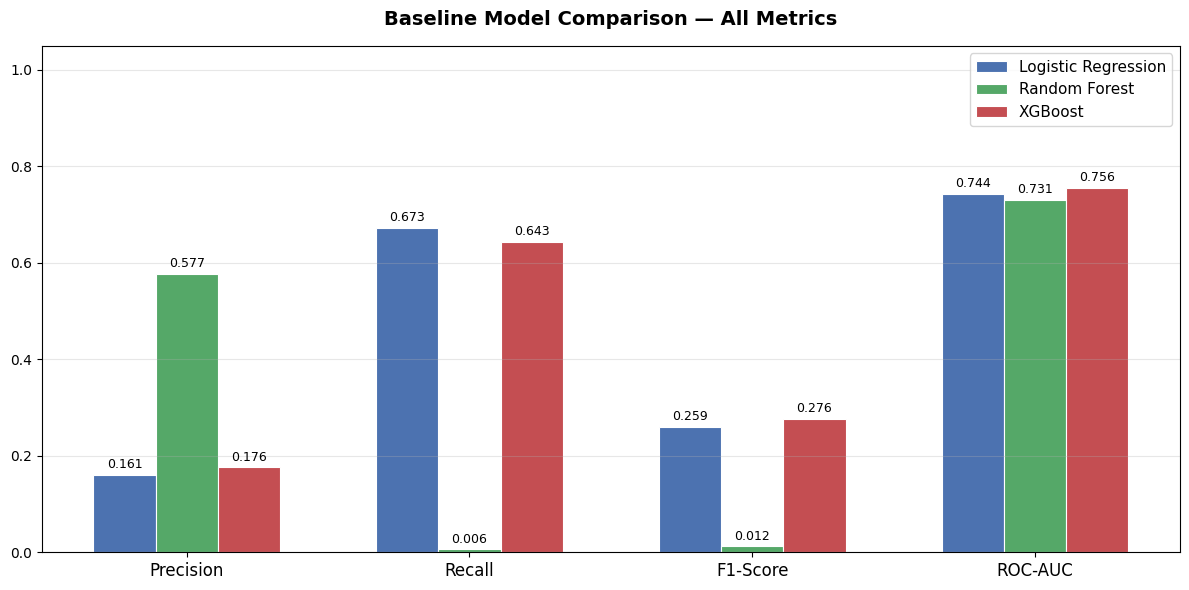

In [13]:
# --- Bar Chart: All Metrics Side-by-Side ---
fig, ax = plt.subplots(figsize=(12, 6))

metrics = ['Precision', 'Recall', 'F1-Score', 'ROC-AUC']
models = comparison_df.index.tolist()
x = np.arange(len(metrics))
width = 0.22

colors = ['#4C72B0', '#55A868', '#C44E52']

for i, model in enumerate(models):
    values = [comparison_df.loc[model, m] for m in metrics]
    bars = ax.bar(x + i * width, values, width, label=model, color=colors[i], edgecolor='white', linewidth=0.8)
    for bar, val in zip(bars, values):
        ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.008,
                f'{val:.3f}', ha='center', va='bottom', fontsize=9)

ax.set_xticks(x + width)
ax.set_xticklabels(metrics, fontsize=12)
ax.set_ylim(0, 1.05)
ax.set_title('Baseline Model Comparison — All Metrics', fontsize=14, fontweight='bold', pad=15)
ax.legend(fontsize=11)
ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

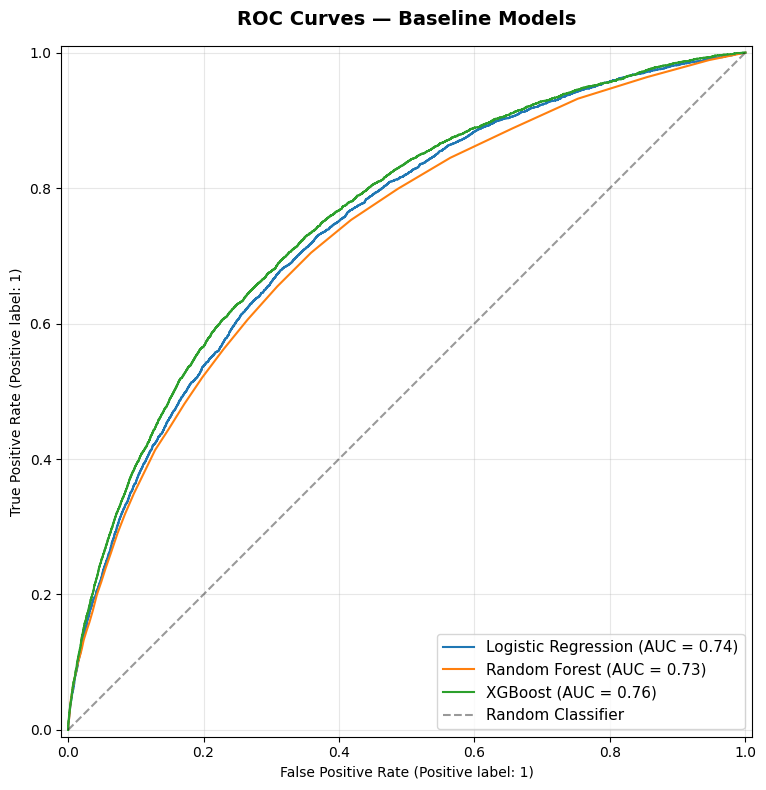

In [14]:
# --- ROC Curves ---
fig, ax = plt.subplots(figsize=(8, 8))

baseline_models = {
    'Logistic Regression': lr_model,
    'Random Forest': rf_model,
    'XGBoost': xgb_model
}

for name, model in baseline_models.items():
    RocCurveDisplay.from_estimator(model, X_val_scaled, y_val, ax=ax, name=name)

ax.plot([0, 1], [0, 1], 'k--', alpha=0.4, label='Random Classifier')
ax.set_title('ROC Curves — Baseline Models', fontsize=14, fontweight='bold', pad=15)
ax.legend(fontsize=11, loc='lower right')
ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()

## 12. Feature Importance (XGBoost)

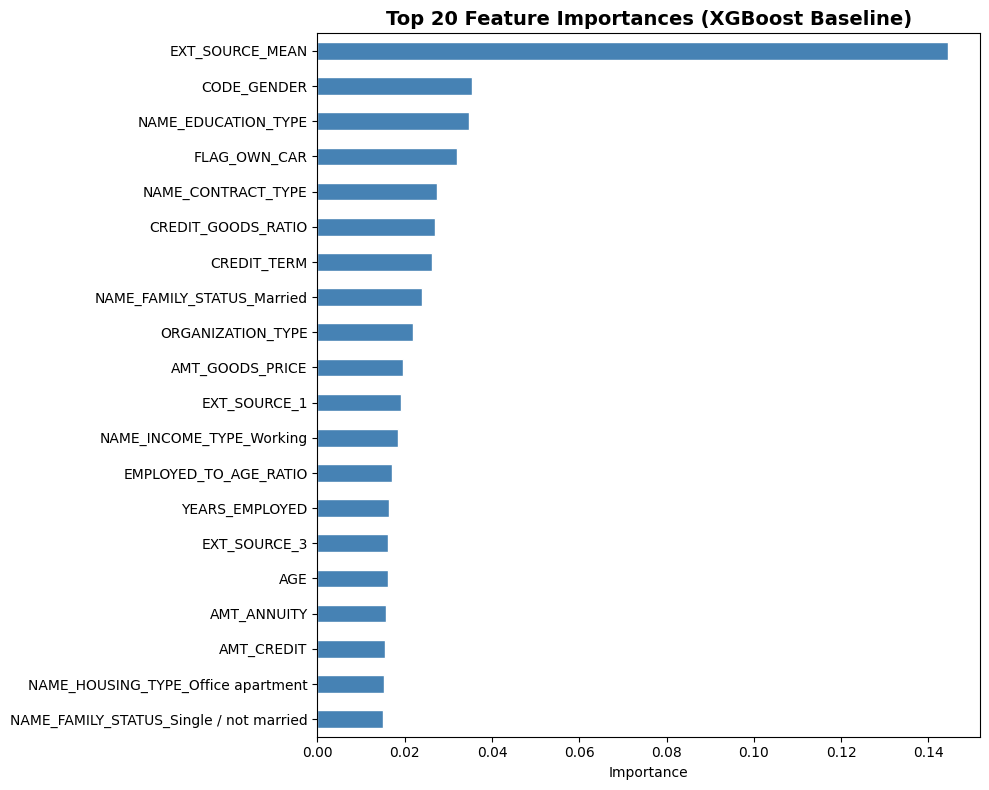

In [15]:
# Top 20 most important features from XGBoost
feature_importance = pd.Series(
    xgb_model.feature_importances_,
    index=X.columns
).sort_values(ascending=True)

fig, ax = plt.subplots(figsize=(10, 8))
feature_importance.tail(20).plot(kind='barh', ax=ax, color='steelblue', edgecolor='white')
ax.set_title('Top 20 Feature Importances (XGBoost Baseline)', fontsize=14, fontweight='bold')
ax.set_xlabel('Importance')
plt.tight_layout()
plt.show()